In [1]:
import sys
sys.path.insert(0, '../simulation')

import numpy as np
import matplotlib.pyplot as plt

from resources import (
    ResourceType,
    ResourceConfig,
    DEFAULT_RESOURCE_CONFIGS,
    sample_distribution,
)
from solar_system import Planet, SolarSystem
from buildings import BuildingType, ResourceType
from colony import Colony, Faction, DirectiveType
from snapshot import take_snapshot, plot_history

from tqdm import tqdm

R = ResourceType

In [ ]:
# --- Build a faction with one colony for testing ---
faction = Faction(faction_id=0, name="Test Faction")

home = Colony(
    colony_id  = 0,
    name       = "Main Colony",
    system_id  = 0,
    population = 800.0,
    stockpile  = {
        int(R.MINERALS): 2000.0,
        int(R.ENERGY):    500.0,
        int(R.ORGANICS): 8000.0,
        int(R.RARE_MATS):  20.0,
    },
)

# add colony to faction
faction.add_colony(home)

# Seed some buildings
home.construct_building(BuildingType.FARM,        planet_index=0)
home.construct_building(BuildingType.MINE,        planet_index=0)
home.construct_building(BuildingType.POWER_PLANT, planet_index=0)
home.construct_building(BuildingType.LAB,         planet_index=0)
home.recruit_workers(20)

faction.issue_directive(0, DirectiveType.EXPAND, tax_rate=0.1, urgency=0.5)

# run 20 ticks to generate some data
history = []
tick_number = 500
for t in range(1, tick_number + 1):
    faction.tick()
    history.append(take_snapshot(faction.colonies[0]))

colony_name = faction.colonies[0].name


======   Tick 1   ======
======   Tick 2   ======
======   Tick 3   ======
======   Tick 4   ======
======   Tick 5   ======
======   Tick 6   ======
======   Tick 7   ======
======   Tick 8   ======
Colony Main Colony (id=0):  FARM lv1 (id=0) construction complete.
Colony Main Colony (id=0):  Assigned 5 worker(s) to FARM lv1 (id=0).
Colony Main Colony (id=0):  Building new farm to raise organics rate.
======   Tick 9   ======
Colony Main Colony (id=0):  Building new farm to raise organics rate.
======   Tick 10   ======
Colony Main Colony (id=0):  MINE lv1 (id=1) construction complete.
Colony Main Colony (id=0):  Assigned 4 worker(s) to MINE lv1 (id=1).
Colony Main Colony (id=0):  Building new farm to raise organics rate.
======   Tick 11   ======
Colony Main Colony (id=0):  Building new farm to raise organics rate.
======   Tick 12   ======
Colony Main Colony (id=0):  POWER_PLANT lv1 (id=2) construction complete.
Colony Main Colony (id=0):  ⚠ POWER_PLANT lv1 (id=2) INACTIVE — worker 

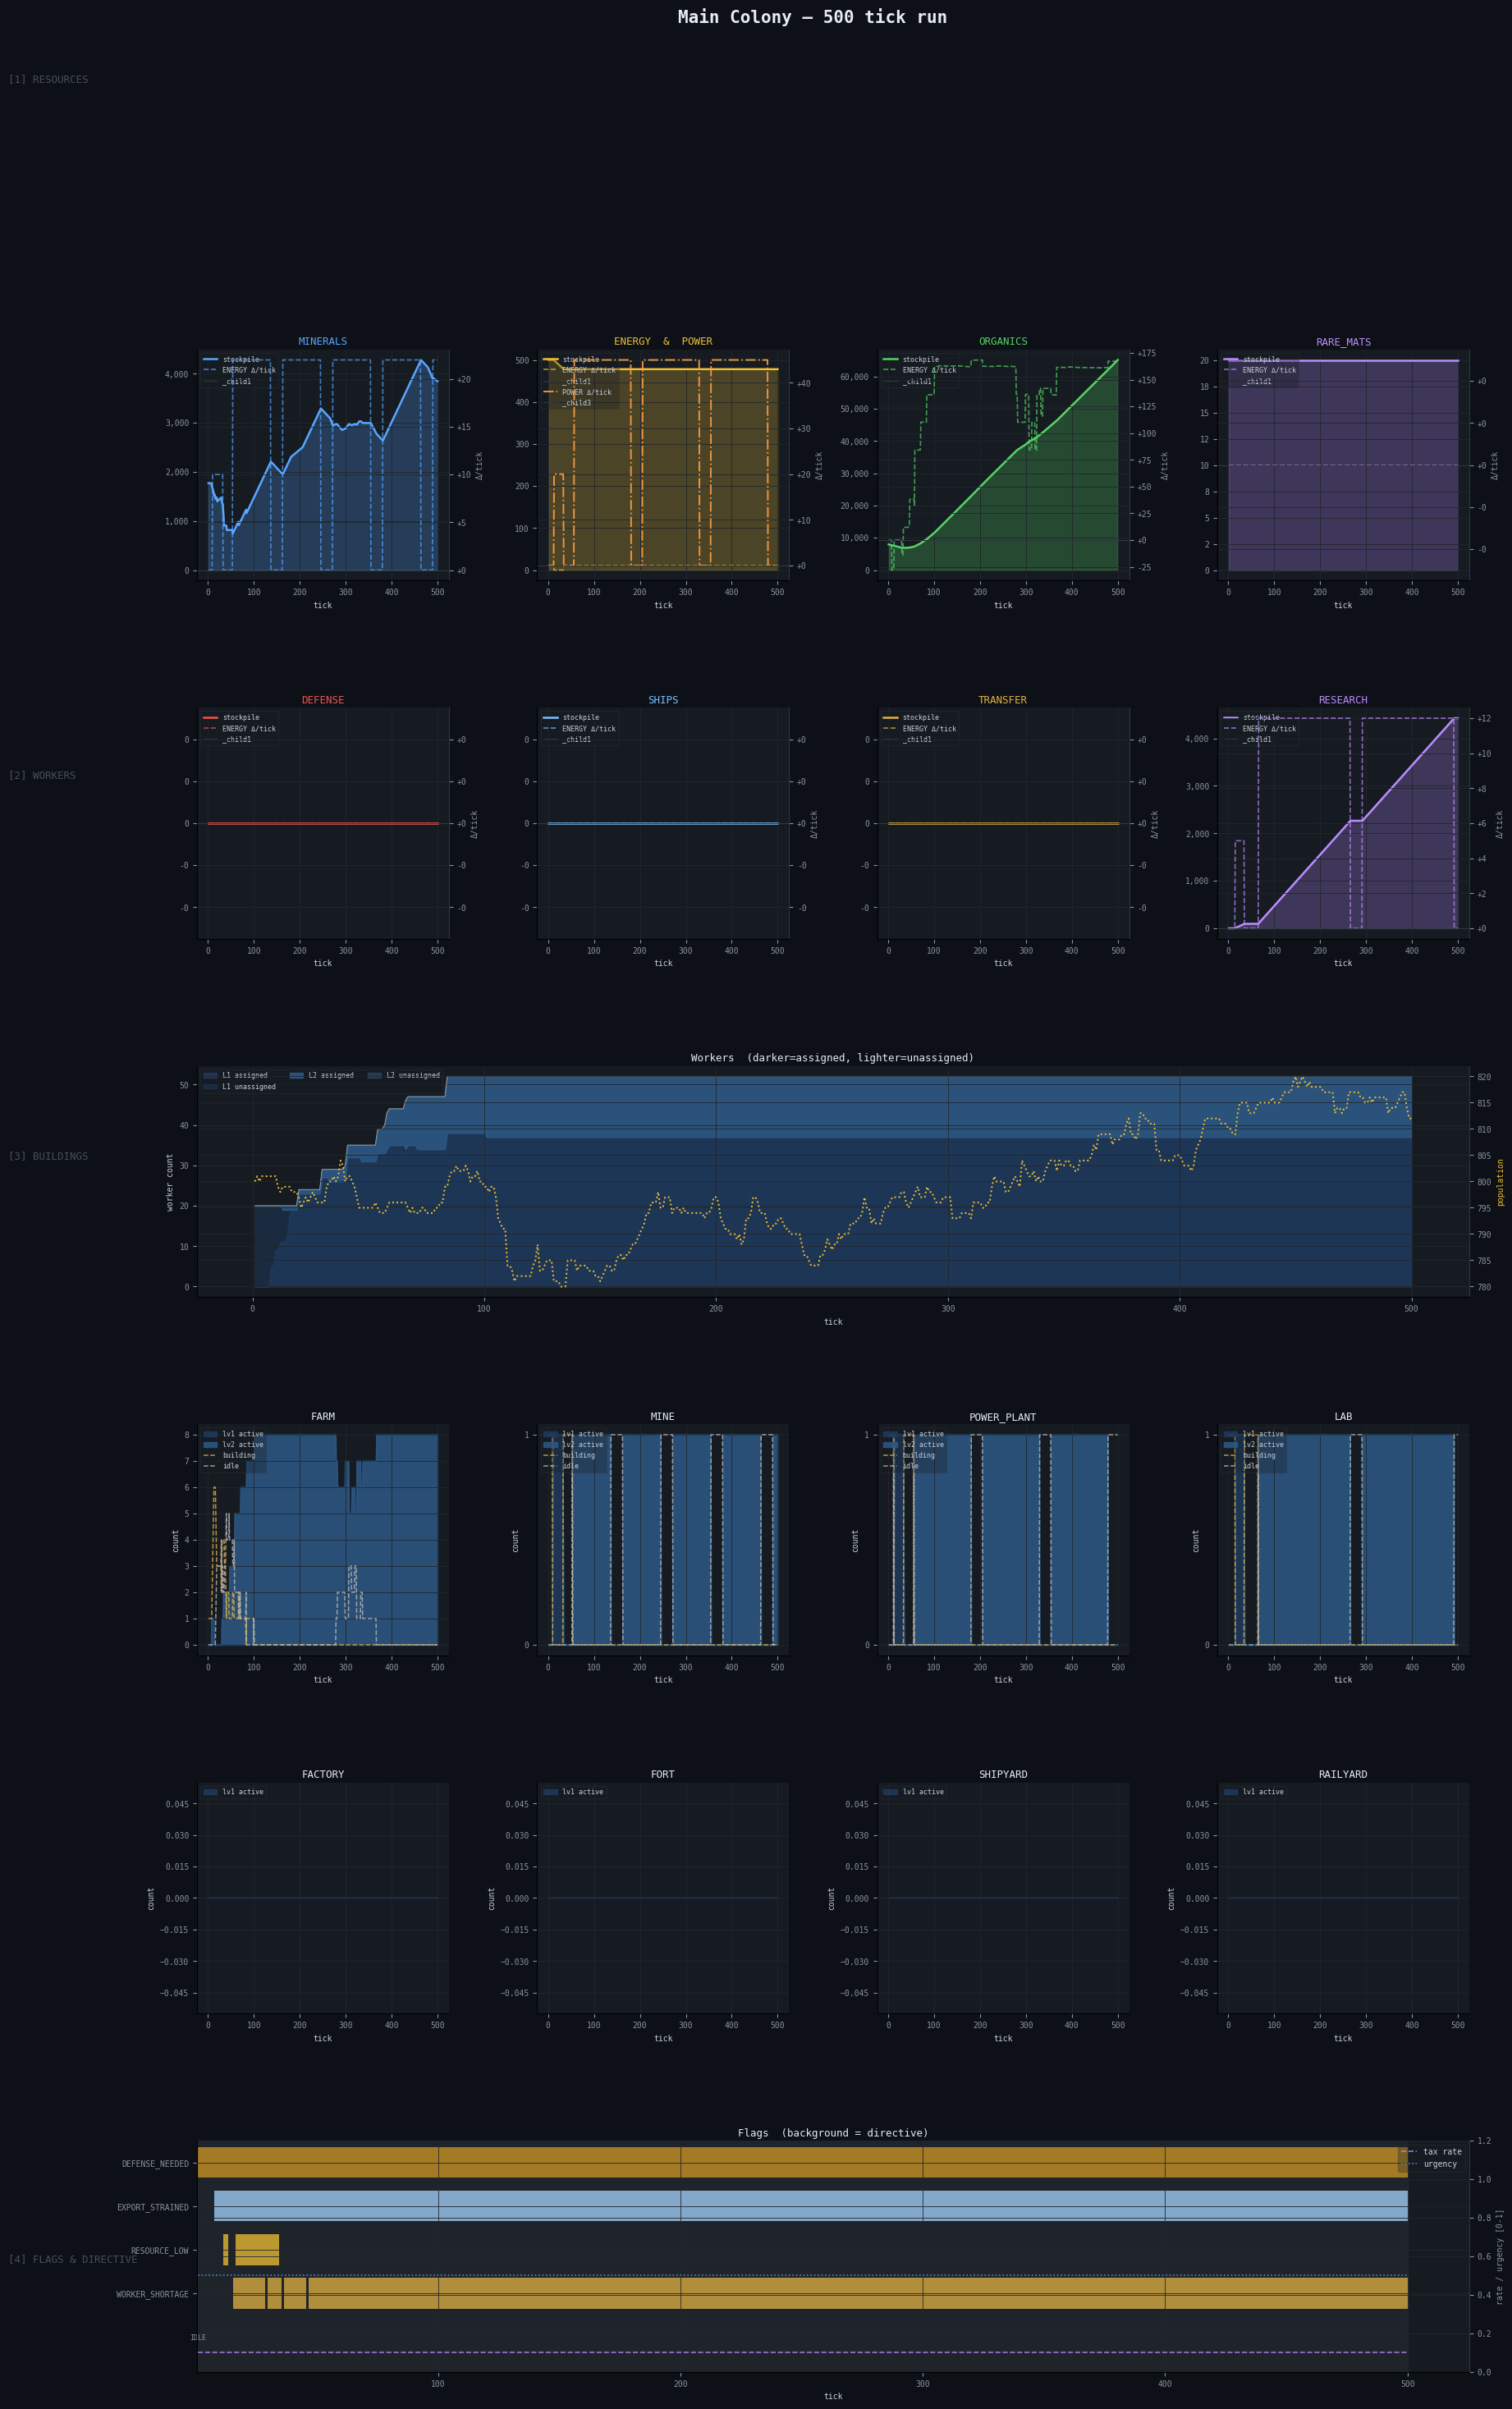

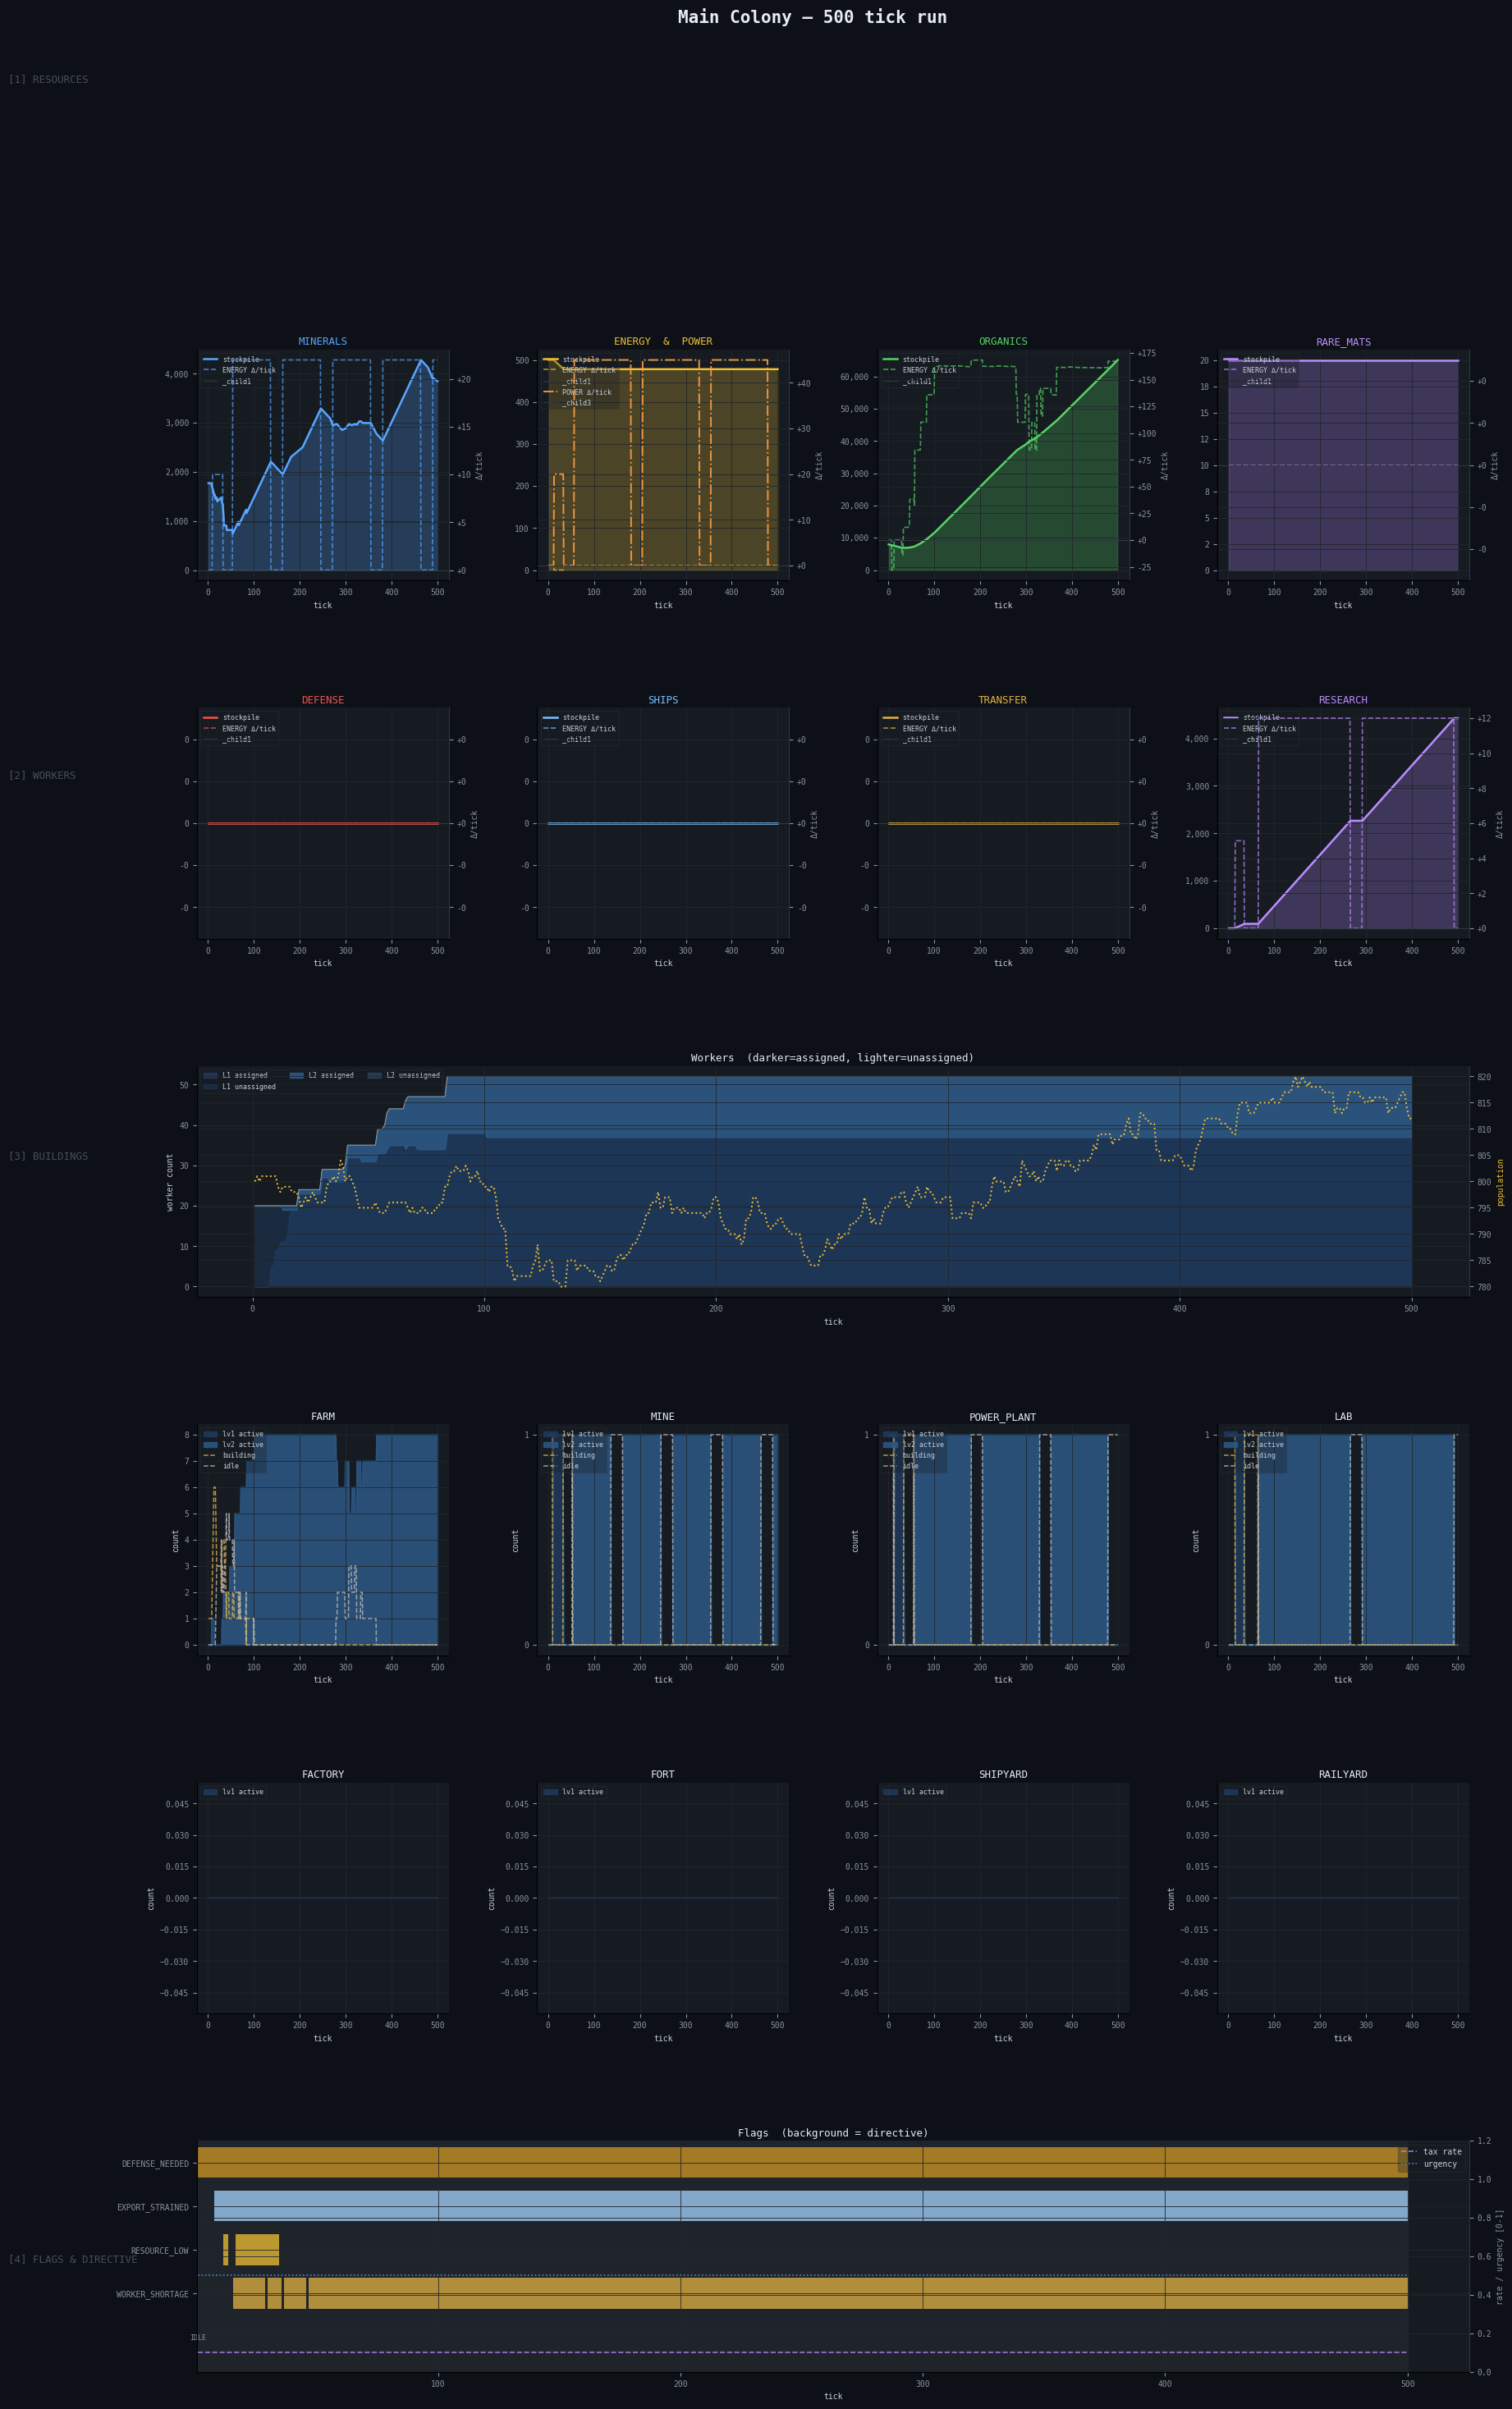

In [3]:
plot_history(history, title=f"{colony_name} — {tick_number} tick run", save_path=f"run_{tick_number}ticks.png")

In [4]:
print("\n===== NET RATE OUTPUT =====")
for rt, val in faction.colonies[0]._net_rates().items():
    print(f"Net {rt.name}: {val:.2f}")
print("\n===== BUILDING COUNTS =====")
for bt, val in faction.colonies[0].building_counts.items():
    print(f"{bt} count: {val}")


===== NET RATE OUTPUT =====
Net MINERALS: 22.00
Net ORGANICS: 167.40

===== BUILDING COUNTS =====
(<BuildingType.FARM: 2>, 2) count: 8
(<BuildingType.MINE: 0>, 2) count: 1


In [5]:
for i in range(8):
    print(i%4)

0
1
2
3
0
1
2
3
